In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [16]:
mort = pd.read_csv('../data/Mortality_US_by_County_All_Races_All_Malignant_Cancers_(Both_Sexes)_2019_-_2023.csv', skiprows=1)
svi = pd.read_csv('../data/SVI_2022_US_county.csv')
mort.head()

,Area,County FIPS,"Age-Adjusted Rate per 100,000",Lower CI,Upper CI,Count
0,"Union, Florida",12125,412.24,372.14,455.73,403
1,"Kingman, Kansas",20095,359.67,308.40,417.87,195
2,"Todd, South Dakota",46121,273.95,210.87,348.41,74
3,"Galax, Virginia",51640,273.07,224.75,329.24,119
4,"Humphreys, Mississippi",28053,269.22,223.81,321.68,135


In [17]:
mort.columns = ['Area', 'FIPS', 'rate', 'lower', 'upper', 'count']
mort = mort[mort['FIPS'] != '00000']
mort = mort[~mort['rate'].isin(['No Data/Suppressed', 'Suppressed'])]
mort['FIPS'] = mort['FIPS'].astype(str).str.zfill(5)
mort['rate'] = pd.to_numeric(mort['rate'], errors='coerce')
mort.dropna(subset=['rate'], inplace=True)
mort.shape

(2000, 6)

In [18]:
svi['FIPS'] = svi['FIPS'].astype(str).str.zfill(5)
ep = [c for c in svi.columns if c.startswith('EP_')]
df = mort[['FIPS','Area','rate']].merge(svi[['FIPS'] + ep], on='FIPS')
df.shape

(1998, 27)

In [19]:
X = df[ep].copy()
X = X.replace(-999, np.nan)
X = X.fillna(X.median())
y = df['rate']
y.describe()

count    1998.000000
mean      178.743388
std        21.673610
min       152.430000
25%       162.960000
50%       173.945000
75%       188.895000
max       412.240000
Name: rate, dtype: float64

In [26]:
top_features = corr[corr > 0.1].index.tolist()
print("Using features:", len(top_features))

X2 = df[top_features].copy().replace(-999, np.nan).fillna(df[top_features].median())
y = df['rate']

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

preds = model.predict(X_test)
print("R²:", r2_score(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("MAE:", mean_absolute_error(y_test, preds))

Using features: 15
R²: 0.2631477391695993
RMSE: 16.96236548999134
MAE: 12.85686447753906


In [29]:
incd = pd.read_csv('../data/incd.csv', skiprows=8, on_bad_lines='skip')
print(incd.shape)
print(incd.columns.tolist())
incd.head()

(3161, 14)
['County', 'FIPS', '2023 Rural-Urban Continuum Codes([rural urban note])', 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000', 'Lower 95% Confidence Interval', 'Upper 95% Confidence Interval', 'CI*Rank([rank note])', 'Lower CI (CI*Rank)', 'Upper CI (CI*Rank)', 'Average Annual Count', 'Recent Trend', 'Recent 5-Year Trend ([trend note]) in Incidence Rates', 'Lower 95% Confidence Interval.1', 'Upper 95% Confidence Interval.1']


,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,US (SEER+NPCR)(1),0.0,NaN,448.6,448.3,448.9,N/A,N/A,N/A,1821045,falling,-1.0,-1.6,-0.5
1,"Union County, Florida(2)",12125.0,Rural,1215,1144.9,1288.5,N/A,N/A,N/A,237,stable,0.3,-0.6,1.2
2,"Polk County, Texas(7)",48373.0,Rural,683.8,651.9,716.9,N/A,N/A,N/A,440,stable,-1.7,-3.9,0.8
3,"McPherson County, Nebraska(2)",31117.0,Rural,677,377.1,1145.8,N/A,N/A,N/A,4,*,*,*,*
4,"Dewey County, South Dakota(2)",46041.0,Rural,649.8,543.8,769.7,N/A,N/A,N/A,29,stable,1.4,-0.5,3.4


In [30]:
incd.columns = ['County', 'FIPS', 'Rural_Urban', 'Incidence_Rate',
                'Inc_Lower', 'Inc_Upper', 'CI_Rank', 'CR_Lower', 'CR_Upper',
                'Avg_Count', 'Recent_Trend', 'Trend_5yr', 'T_Lower', 'T_Upper']

incd = incd[~incd['Incidence_Rate'].isin(['*', 'N/A', 'Suppressed', 'No Data/Suppressed'])]
incd['FIPS'] = incd['FIPS'].astype(str).str.zfill(5)
incd['Incidence_Rate'] = pd.to_numeric(incd['Incidence_Rate'], errors='coerce')
incd = incd.dropna(subset=['Incidence_Rate'])

# merge with main df
df2 = df.merge(incd[['FIPS', 'Incidence_Rate']], on='FIPS', how='inner')
print("New merged rows:", len(df2))

New merged rows: 0


In [31]:
print("incd FIPS sample:", incd['FIPS'].head().tolist())
print("df FIPS sample:", df['FIPS'].head().tolist())

incd FIPS sample: ['000.0', '12125.0', '48373.0', '31117.0', '46041.0']
df FIPS sample: ['12125', '20095', '46121', '51640', '28053']


In [32]:
incd['FIPS'] = incd['FIPS'].astype(str).str.replace('.0', '', regex=False).str.zfill(5)
incd = incd[incd['FIPS'] != '00000']

df2 = df.merge(incd[['FIPS', 'Incidence_Rate']], on='FIPS', how='inner')
print("New merged rows:", len(df2))

New merged rows: 1933


In [25]:
incd = pd.read_csv('../data/incd.csv', skiprows=8, on_bad_lines='skip')
print(incd.shape)
print(incd.columns.tolist())
incd.head()

EP_POV150     0.419432
EP_DISABL     0.355939
EP_NOHSDP     0.354096
EP_NOINT      0.318846
EP_MOBILE     0.264428
EP_UNEMP      0.240608
EP_MUNIT      0.231561
EP_ASIAN      0.181716
EP_NOVEH      0.173917
EP_UNINSUR    0.172165
EP_AIAN       0.170327
EP_SNGPNT     0.152614
EP_CROWD      0.141762
EP_AGE17      0.116556
EP_AFAM       0.101927
Name: rate, dtype: float64


In [21]:
print("Merged rows:", len(df))
print("Target stats:")
print(y.describe())
print("\nMissing in X:", X.isnull().sum().sum())
print("\nSample of merged data:")
df[['Area', 'rate', 'EP_POV150', 'EP_UNINSUR', 'EP_NOHSDP']].head(10)

Merged rows: 1998
Target stats:
count    1998.000000
mean      178.743388
std        21.673610
min       152.430000
25%       162.960000
50%       173.945000
75%       188.895000
max       412.240000
Name: rate, dtype: float64

Missing in X: 0

Sample of merged data:


,Area,rate,EP_POV150,EP_UNINSUR,EP_NOHSDP
0,"Union, Florida",412.24,24.3,11.4,22.1
1,"Kingman, Kansas",359.67,16.5,9.5,9.2
2,"Todd, South Dakota",273.95,66.6,27.6,20.2
3,"Galax, Virginia",273.07,37.7,14.4,19.8
4,"Humphreys, Mississippi",269.22,56.5,15.5,25.2
5,"Owsley, Kentucky",265.77,38.1,4.5,28.6
6,"Polk, Texas",265.71,25.9,16.7,18.6
7,"Thurston, Nebraska",263.84,31.4,17.6,10.2
8,"Ripley, Missouri",262.84,34.9,16.9,17.8
9,"Tunica, Mississippi",259.53,48.7,13.1,16.4


In [22]:
print("Mort FIPS sample:", mort['FIPS'].head().tolist())
print("SVI FIPS sample:", svi['FIPS'].head().tolist())
print("\nMort FIPS type:", mort['FIPS'].dtype)
print("SVI FIPS type:", svi['FIPS'].dtype)

Mort FIPS sample: ['12125', '20095', '46121', '51640', '28053']
SVI FIPS sample: ['01001', '01003', '01005', '01007', '01009']

Mort FIPS type: str
SVI FIPS type: str


In [23]:
print("Mort unique FIPS:", mort['FIPS'].nunique())
print("SVI unique FIPS:", svi['FIPS'].nunique())

# Let's see which FIPS codes in mort are not in SVI
missing = set(mort['FIPS']) - set(svi['FIPS'])
print("\nFIPS in mort but not in SVI:", len(missing))
print("Examples:", list(missing)[:10])

Mort unique FIPS: 2000
SVI unique FIPS: 3144

FIPS in mort but not in SVI: 2
Examples: ['09015', '51917']


In [33]:
ep2 = ep + ['Incidence_Rate']
X3 = df2[ep2].copy().replace(-999, np.nan).fillna(df2[ep2].median())
y3 = df2['rate']

X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

model2 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    random_state=42
)
model2.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

preds2 = model2.predict(X_test)
print("R²:", r2_score(y_test, preds2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds2)))
print("MAE:", mean_absolute_error(y_test, preds2))

R²: 0.36889242522080845
RMSE: 15.413988282903535
MAE: 11.691914125585434


In [34]:
# Remove outliers
q_low = df2['rate'].quantile(0.01)
q_high = df2['rate'].quantile(0.99)
df3 = df2[(df2['rate'] >= q_low) & (df2['rate'] <= q_high)]
print("After removing outliers:", len(df3))

ep2 = ep + ['Incidence_Rate']
X4 = df3[ep2].copy().replace(-999, np.nan).fillna(df3[ep2].median())
y4 = df3['rate']

X_train, X_test, y_train, y_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

model3 = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    random_state=42
)
model3.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

preds3 = model3.predict(X_test)
print("R²:", r2_score(y_test, preds3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds3)))
print("MAE:", mean_absolute_error(y_test, preds3))

After removing outliers: 1893
R²: 0.3665716248027887
RMSE: 14.472846210684157
MAE: 11.414476761226602


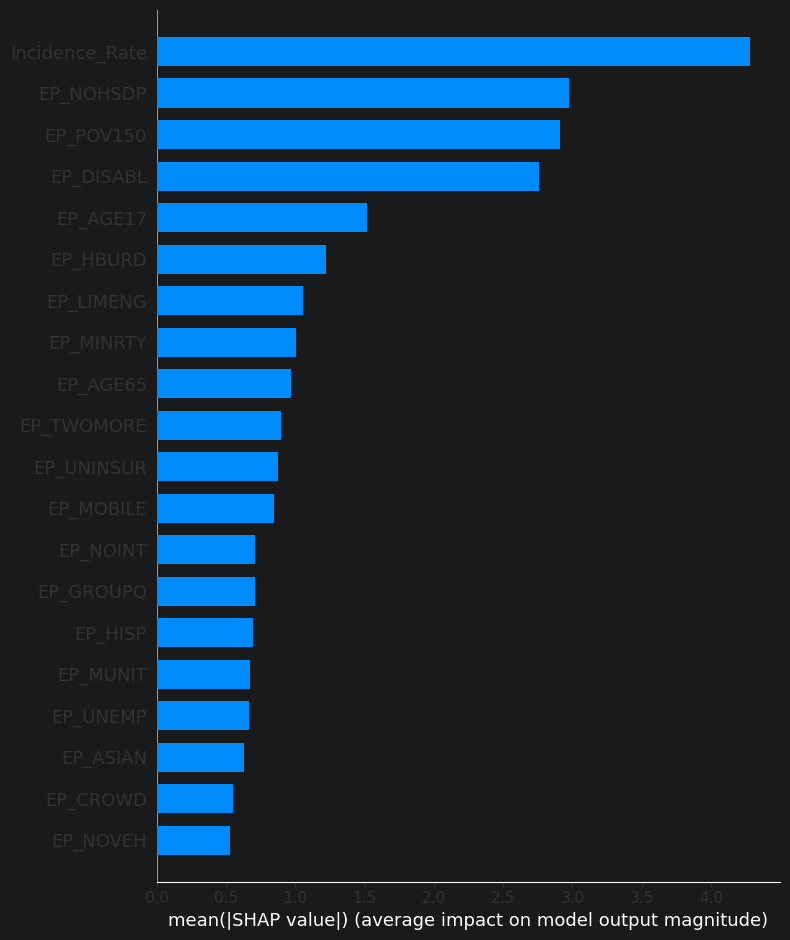

Saved!


In [35]:
explainer = shap.TreeExplainer(model2)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('../visualizations/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

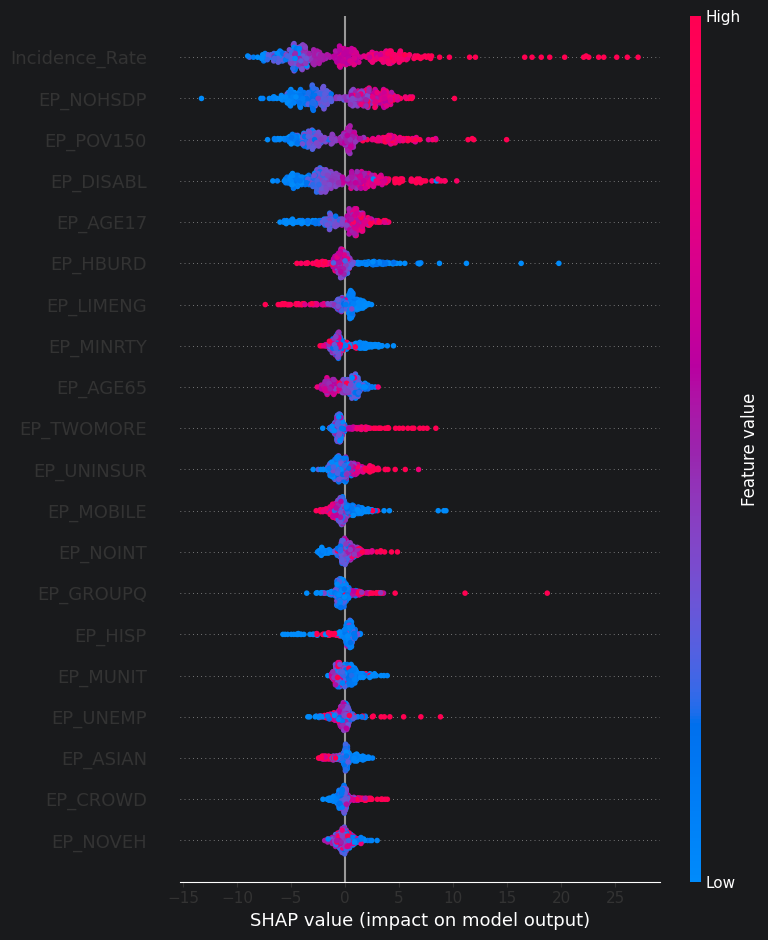

Saved!


In [36]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../visualizations/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [37]:
import plotly.express as px

df2['FIPS'] = df2['FIPS'].astype(str).str.zfill(5)

fig = px.choropleth(
    df2,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='FIPS',
    color='rate',
    color_continuous_scale='Reds',
    scope='usa',
    labels={'rate': 'Cancer Mortality Rate'},
    title='Cancer Mortality Rate by US County (2019-2023)'
)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.write_html('../visualizations/cancer_mortality_map.html')
fig.show()
print("Saved!")

Saved!


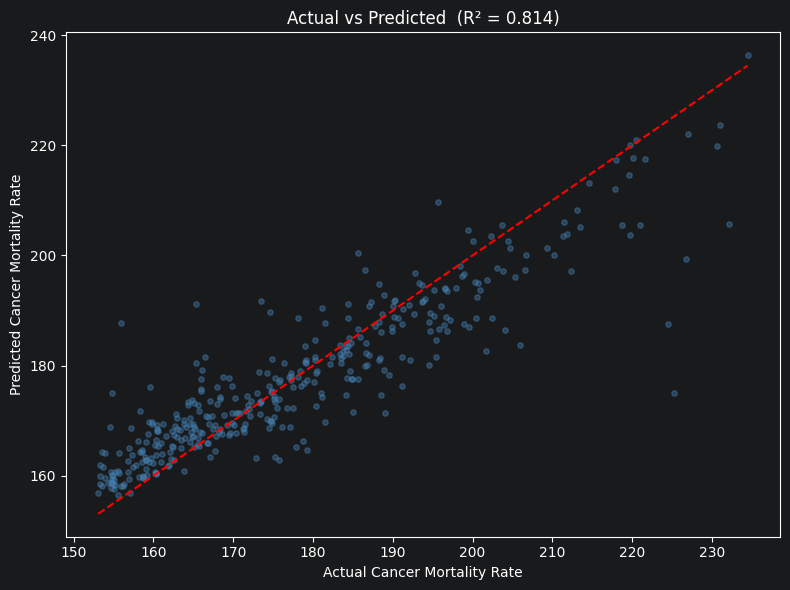

Saved!


In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

# Generate predictions on X_test
preds_plot = model2.predict(X_test)

ax.scatter(y_test, preds_plot, alpha=0.4, s=15, color='steelblue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
ax.set_xlabel('Actual Cancer Mortality Rate')
ax.set_ylabel('Predicted Cancer Mortality Rate')
ax.set_title(f'Actual vs Predicted  (R² = {r2_score(y_test, preds_plot):.3f})')
plt.tight_layout()
plt.savefig('../visualizations/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")